# HICASM — minimal capability demo

This notebook demonstrates the canonical **Hippocampal-Inspired Content-Addressable Sequence Memory (HICASM)** pathway $R\to C\to A\to B\to S\to R$. HICASM retains only the largest episode evidence $D_{k^*}$, but obtains the recovered barcode through the stored A$\to B$ association. The demonstrations cover partial-context retrieval, a unique-event cue, and ambiguity resolved by one additional event.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from hicasm import HICASM, sample_unique_sequences

plt.style.use('seaborn-v0_8-whitegrid')
t0 = time.perf_counter()
model = HICASM()
print({
    'model': 'HICASM',
    'competition': 'deterministic episode-level hard WTA',
    'theta_B': model.theta_B,
    'initialization_seconds': time.perf_counter() - t0,
})

{'model': 'HICASM', 'competition': 'deterministic episode-level hard WTA', 'theta_B': 0.6694013233926478, 'initialization_seconds': 1.910669624999855}


## 1. Partial-context retrieval

Store $M=25$ length-8 episodes once. Query each episode using a prefix, middle fragment, or suffix of length $m\in\{2,3,4\}$. Exact replay requires all eight retrieved relations to be correct.

In [2]:
rng = np.random.default_rng(12001)
M, L = 25, 8
episodes = sample_unique_sequences(rng, model.config.N_R, L, M)
memory = model.build_memory(episodes)
indexed = model.indexed_replay(memory)
indexed_exact = float(np.mean(np.all(indexed == episodes, axis=1)))

partial = {}
for location in ('prefix', 'middle', 'suffix'):
    partial[location] = []
    for m in (2, 3, 4):
        start = 0 if location == 'prefix' else (L - m) // 2 if location == 'middle' else L - m
        out = model.replay(memory, episodes[:, start:start + m])
        partial[location].append(float(np.mean(np.all(out['predicted'] == episodes, axis=1))))
print({'indexed_exact_replay': indexed_exact, 'partial_exact_replay': partial})

{'indexed_exact_replay': 1.0, 'partial_exact_replay': {'prefix': [1.0, 1.0, 1.0], 'middle': [0.96, 1.0, 1.0], 'suffix': [0.76, 1.0, 1.0]}}


## 2. Unique-event addressing

Each of $M=25$ episodes receives one marker relation at position 4. Marker relations are excluded from every filler position, so a one-event cue identifies exactly one stored episode.

In [3]:
rng = np.random.default_rng(13001)
markers = rng.choice(model.config.N_R, M, replace=False)
filler_pool = np.setdiff1d(np.arange(model.config.N_R), markers)
unique_episodes = []
for marker in markers:
    filler = rng.choice(filler_pool, 7, replace=False)
    unique_episodes.append(np.r_[filler[:3], marker, filler[3:]])
unique_episodes = np.asarray(unique_episodes)
unique_memory = model.build_memory(unique_episodes)
unique_out = model.replay(unique_memory, unique_episodes[:, 3:4])
unique_address = float(np.mean(unique_out['winner'] == np.arange(M)))
unique_exact = float(np.mean(np.all(unique_out['predicted'] == unique_episodes, axis=1)))
print({'unique_event_addressing': unique_address, 'unique_event_exact_replay': unique_exact})

{'unique_event_addressing': 1.0, 'unique_event_exact_replay': 1.0}


## 3. Ambiguity and one-event disambiguation

In each of 12 independently generated memory banks, two episodes share a three-event cue. Hard WTA selects one compatible episode rather than mixing their barcodes. Adding the following target-specific event should select and replay the target.

In [4]:
ambiguous_winners = {'target': 0, 'partner': 0, 'other': 0}
disambiguated_exact = []
for bank in range(12):
    rng = np.random.default_rng(14001 + bank)
    bank_episodes = sample_unique_sequences(rng, model.config.N_R, L, 50)
    shared = rng.choice(model.config.N_R, 3, replace=False)
    remaining = np.setdiff1d(np.arange(model.config.N_R), shared)
    discriminators = rng.choice(remaining, 2, replace=False)
    bank_episodes[0, 2:5] = shared
    bank_episodes[1, 2:5] = shared
    bank_episodes[0, 5] = discriminators[0]
    bank_episodes[1, 5] = discriminators[1]
    bank_memory = model.build_memory(bank_episodes)

    ambiguous = model.replay(bank_memory, bank_episodes[0:1, 2:5])
    winner = int(ambiguous['winner'][0])
    ambiguous_winners['target' if winner == 0 else 'partner' if winner == 1 else 'other'] += 1

    resolved = model.replay(bank_memory, bank_episodes[0:1, 2:6])
    disambiguated_exact.append(np.array_equal(resolved['predicted'][0], bank_episodes[0]))

ambiguous_probability = {k: v / 12 for k, v in ambiguous_winners.items()}
resolved_probability = float(np.mean(disambiguated_exact))
print({'ambiguous_winner_probability': ambiguous_probability,
       'disambiguated_target_exact_replay': resolved_probability})

{'ambiguous_winner_probability': {'target': 0.5, 'partner': 0.5, 'other': 0.0}, 'disambiguated_target_exact_replay': 1.0}


## Summary figure

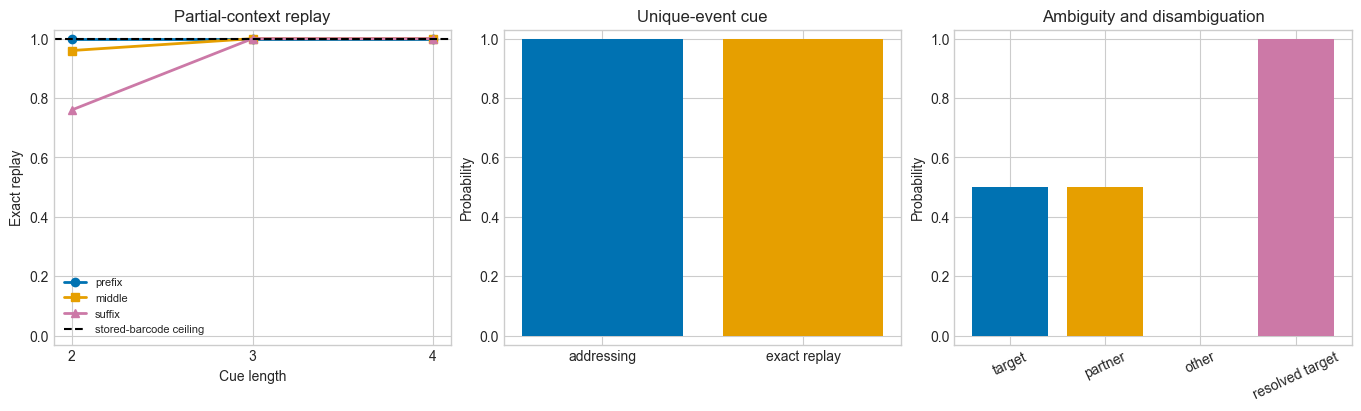

In [5]:
colors = {'prefix': '#0072B2', 'middle': '#E69F00', 'suffix': '#CC79A7'}
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), constrained_layout=True)

for location, marker in zip(('prefix', 'middle', 'suffix'), ('o', 's', '^')):
    axes[0].plot((2, 3, 4), partial[location], marker=marker, lw=2,
                 color=colors[location], label=location)
axes[0].axhline(indexed_exact, color='black', ls='--', label='stored-barcode ceiling')
axes[0].set(title='Partial-context replay', xlabel='Cue length', ylabel='Exact replay',
            xticks=(2, 3, 4), ylim=(-0.03, 1.03))
axes[0].legend(fontsize=8)

axes[1].bar(('addressing', 'exact replay'), (unique_address, unique_exact),
            color=('#0072B2', '#E69F00'))
axes[1].set(title='Unique-event cue', ylabel='Probability', ylim=(-0.03, 1.03))

labels = ('target', 'partner', 'other', 'resolved target')
values = (ambiguous_probability['target'], ambiguous_probability['partner'],
          ambiguous_probability['other'], resolved_probability)
axes[2].bar(labels, values, color=('#0072B2', '#E69F00', '#999999', '#CC79A7'))
axes[2].set(title='Ambiguity and disambiguation', ylabel='Probability', ylim=(-0.03, 1.03))
axes[2].tick_params(axis='x', rotation=25)
plt.show()

The demo distinguishes three claims: downstream storage can replay an indexed episode; partial contextual evidence can address stored episodes; and hard WTA represents ambiguity as selection across trials rather than an uninterpretable mixture of two barcodes.